# Physical Activity - ENMO Analysis 
**GitHub repository:* [My GitHub repository](https://github.com/Aminata-MOUSSA/HAH913E-Physical-Activity-00.git)

**Team member:**
- Aminata MOUSSA
- Ndiaya DIENG
- Ifetayo HOUESSIONON 
- Noam GREA 

## Objective 
The objective of this notebook is to analyse raw accelerometer data recorded from an Axivity AX3 accelerometer worn on the non-dominant wrist.
The ENMO will be calculated from the three acceleration axes (x, y, z) and integrated over different epoch lenghts: 10s, 30s and 60s.

## Import libraries 
The following libraries are used for data manipulation, numerical calculations and data visualization.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [41]:
df= pd.read_csv("0_z.csv", comment="#")
df.head()

,t,x,y,z
0,0.00,-0.0938,-0.0156,0.9531
1,0.02,-0.0938,-0.0156,0.9531
2,0.04,-0.0938,-0.0156,0.9531
3,0.06,-0.0938,-0.0156,0.9531
4,0.08,-0.0938,-0.0156,0.9531


## Data inspection

Before calculating ENMO, the dataset is inspected to verify its structure, dimensions and the presence of missing values.

In [42]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(", ".join(df.columns))

print("\nMissing values:")
for column in df.columns:
    print(f"{column}: {df[column].isnull().sum()}")

print("\nData types:")
for column in df.columns:
    print(f"{column}: {df[column].dtype}")

Dataset shape: (21000, 4)

Column names:
t, x, y, z

Missing values:
t: 0
x: 0
y: 0
z: 0

Data types:
t: float64
x: float64
y: float64
z: float64


## Sampling frequency 
- The sampling interval is calculated from two consecutive time points.

- The sampling frequency in then obtained as the inverse of the sampling interval. 

The sampling interval and sampling frequency are calculated to determine how many acceleration measurements are recorded per second. This information will be used to define the number of samples corresponding to the 10s, 30s and 60s epochs.

In [43]:
dt = df["t"].iloc[1]- df["t"].iloc[0]
fs = 1/dt

print ("Sampling interval: ", dt, "s")
print ("Sampling frequency: ", fs, "Hz")

Sampling interval:  0.02 s
Sampling frequency:  50.0 Hz


## ENMO calculation 
The Euclidean Norm Minus One (ENMO) is calculated from the three acceleration axes (x, y, z):

ENMO = √(x² + y² + z²) - 1

A function is defined to make the ENMO calculation reusable and easier to apply to the acceleration data.

In [44]:
df["enmo"] = np.sqrt(
    df["x"]**2 +
    df["y"]**2 +
    df["z"]**2
) - 1

df["enmo"].describe()

count    21000.000000
mean         0.016746
std          0.594757
min         -0.889493
25%         -0.042168
50%         -0.042168
75%         -0.013368
max         12.784616
Name: enmo, dtype: float64

In [45]:
def calculate_enmo(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2) - 1

In [46]:
df["enmo"] = calculate_enmo(df["x"], df["y"], df["z"])


In [47]:
df[["t", "enmo"]].head()

,t,enmo
0,0.00,-0.042168
1,0.02,-0.042168
2,0.04,-0.042168
3,0.06,-0.042168
4,0.08,-0.042168


### ENMO integration over epochs
The ENMO values are averaged over different epoch lengths (10 s, 30 s and 60 s) to study the effect of temporal aggregation on physical activity measurements.

At a sampling frequency of 50 Hz, the 10 s, 30 s and 60 s epochs correspond to 500, 1500 and 3000 samples, respectively.

In [36]:
# Epoch durations in seconds
epoch_10s = 10
epoch_30s = 30
epoch_60s = 60

# Number of samples per epoch
samples_10s = int(fs * epoch_10s)
samples_30s = int(fs * epoch_30s)
samples_60s = int(fs * epoch_60s)

# Integrated ENMO
integrated_enmo_10s = (
    df["enmo"]
    .groupby(df.index // samples_10s)
    .sum()
    * epoch_10s / 60
)

integrated_enmo_30s = (
    df["enmo"]
    .groupby(df.index // samples_30s)
    .sum()
    * epoch_30s / 60
)

integrated_enmo_60s = (
    df["enmo"]
    .groupby(df.index // samples_60s)
    .sum()
    * epoch_60s / 60
)

print("Number of 10 s epochs:", len(integrated_enmo_10s))
print("Number of 30 s epochs:", len(integrated_enmo_30s))
print("Number of 60 s epochs:", len(integrated_enmo_60s))

Number of 10 s epochs: 42
Number of 30 s epochs: 14
Number of 60 s epochs: 7


## ENMO Visualization
The ENMO values integrated over 10s, 30s and 60s epochs are visualized as a function of time to compare the effect of the different epoch lengths.

In [48]:
def plot_integrated_enmo(df, epoch, fs):
    # Nombre d'échantillons par epoch
    samples = int(fs * epoch)

    # ENMO intégré
    integrated_enmo = df["enmo"].groupby(df.index // samples).sum() * epoch / 60

    # Temps en minutes
    time_min = df["t"] / 60
    time_epoch = np.arange(len(integrated_enmo)) * epoch / 60

    # Création des deux graphiques (axe x partagé)
    fig, ax = plt.subplots(2, 1, sharex=True)

    # Graphique 1 : ENMO intégré
    ax[0].bar(time_epoch, integrated_enmo, width=(epoch / 60) * 0.95,
              align="edge", color="gray", alpha=0.7)
    ax[0].set_title(f"ENMO integrated over {epoch:.1f} s intervals")
    ax[0].set_ylabel("Integrated ENMO (g.min)")

    # Graphique 2 : ENMO au cours du temps
    ax[1].plot(time_min, df["enmo"], alpha=0.5)
    ax[1].set_title("ENMO over Time")
    ax[1].set_xlabel("Time (minutes)")
    ax[1].set_ylabel("ENMO (g)")

    plt.tight_layout()
    plt.show()

    return integrated_enmo

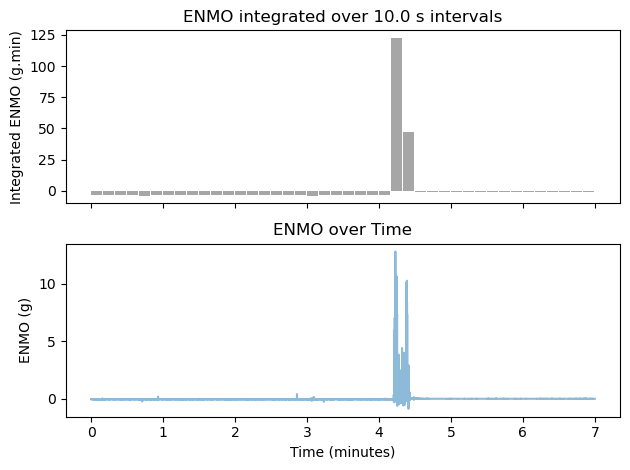

In [49]:
integrated_enmo_10s = plot_integrated_enmo(df, 10, fs)

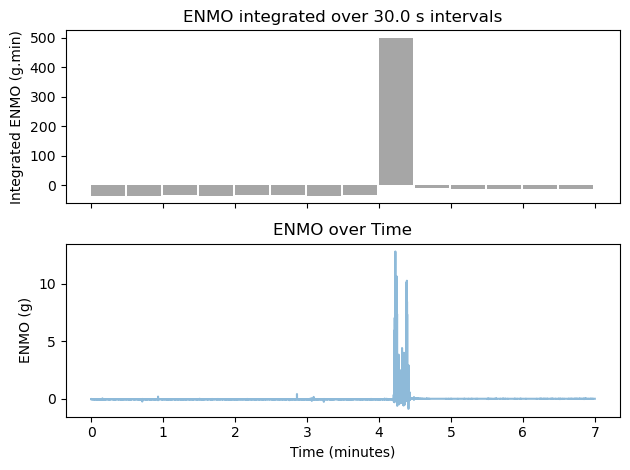

In [50]:
integrated_enmo_30s = plot_integrated_enmo(df, 30, fs)

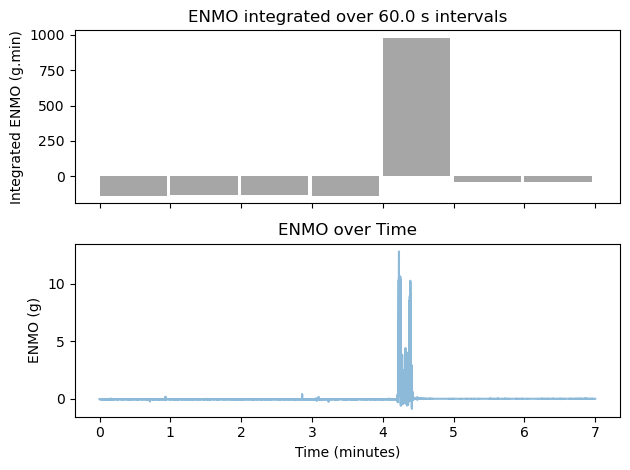

In [51]:
integrated_enmo_60s = plot_integrated_enmo(df, 60, fs)